# Experiment 2: NGRC Analysis of the Recharge Oscillator

This experiment applies NGRC to conceptual ENSO models to investigate whether the learned relationships are consistent with established ENSO dynamics.

## Nonlinear Recharge Oscillator (Jin-type)

$$
\frac{dT_E}{dt} = RT_E + \gamma h_W - e_n (h_W + bT_E)^3
$$

$$
\frac{dh_W}{dt} = -rh_W - \alpha bT_E
$$

where:

- $T_E$: eastern Pacific sea surface temperature anomaly
- $h_W$: western Pacific warm water volume (thermocline depth) anomaly

## Extended Nonlinear Recharge Oscillator (Jin et al. (2020); Vialard et al. (2025))

$$
\frac{dT_E}{dt}
=
RT_E
+F_1h_W
+b_TT_E^2
-c_TT_E^3
+d_TT_Eh_W
+\sigma_T\xi_T\left(1+B_H(T_E)T_E\right)
$$

$$
\frac{dh_W}{dt}
=
-\varepsilon h_W
-F_2T_E
-b_hT_E^2
+\sigma_h\xi_h
$$

Additional nonlinear terms introduce stronger interactions, saturation effects and stochastic forcing to better represent ENSO variability.


### Parameter values used

| Parameter | Value |
|-----------|-------|
| $R$ | 0.50 |
| $\gamma$ | 1.00 |
| $r$ | 0.50 |
| $\alpha$ | 1.00 |
| $b$ | 1.00 |
| $e_n$ | 0.05 |

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from pathlib import Path

In [2]:
# Output directories

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "ro_non_lin"

LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def generate_nonlinear_ro_data(
    dt,
    maxtime,
    R=0.5,
    gamma=1.0,
    r=0.5,
    alpha=1.0,
    b=1.0,
    en=0.05,
):

    t_eval = np.linspace(
        0,
        maxtime,
        int(maxtime / dt) + 1,
    )

    def nonlinear_ro(t, state):

        T, h = state

        return [
            R*T + gamma*h - en*(h + b*T)**3,
            -r*h - alpha*b*T,
        ]

    return solve_ivp(
        nonlinear_ro,
        (0, maxtime),
        [1.0, 0.0],
        t_eval=t_eval,
        method="RK45",
    )

In [4]:
def build_ngrc_features(system_soln, d, k):

    maxtime_pts = system_soln.y.shape[1] - 1

    dlin = d * k

    x = np.zeros((dlin, maxtime_pts))

    for delay in range(k):

        for j in range(delay, maxtime_pts):

            x[
                d * delay:d * (delay + 1),
                j,
            ] = system_soln.y[:, j - delay]

    return x

In [5]:
def train_ngrc(
    x,
    d,
    k,
    warmup_pts,
    warmtrain_pts,
    traintime_pts,
    ridge_param,
    total_var,
):

    dlin = d * k

    dquad = dlin * (dlin + 1) // 2

    dcubic = dlin * (dlin + 1) * (dlin + 2) // 6

    dtot = 1 + dlin + dquad + dcubic

    out_train = np.ones((dtot, traintime_pts))

    out_train[1:dlin+1, :] = x[:, warmup_pts-1:warmtrain_pts-1]

    cnt = 0

    # Quadratic terms

    for i in range(dlin):

        for j in range(i, dlin):

            out_train[dlin+1+cnt, :] = (
                x[i, warmup_pts-1:warmtrain_pts-1]
                * x[j, warmup_pts-1:warmtrain_pts-1]
            )

            cnt += 1

    # Cubic terms

    cnt = 0

    cubic_start = dlin + 1 + dquad

    for i in range(dlin):

        for j in range(i, dlin):

            for m in range(j, dlin):

                out_train[cubic_start+cnt, :] = (

                    x[i, warmup_pts-1:warmtrain_pts-1]

                    * x[j, warmup_pts-1:warmtrain_pts-1]

                    * x[m, warmup_pts-1:warmtrain_pts-1]

                )

                cnt += 1

    Y = (
        x[:d, warmup_pts:warmtrain_pts]
        - x[:d, warmup_pts-1:warmtrain_pts-1]
    )

    W_out = (
        Y @ out_train.T
        @ np.linalg.pinv(
            out_train @ out_train.T
            + ridge_param*np.identity(dtot)
        )
    )

    x_predict = (
        x[:d, warmup_pts-1:warmtrain_pts-1]
        + W_out @ out_train
    )

    train_nrmse = np.sqrt(
        np.mean(
            (
                x[:d, warmup_pts:warmtrain_pts]
                - x_predict
            )**2
        ) / total_var
    )

    return W_out, train_nrmse

In [6]:
def predict_ngrc(
    x,
    W_out,
    d,
    k,
    warmtrain_pts,
    testtime_pts,
    lyaptime_pts,
    total_var,
):

    dlin = d * k

    dquad = dlin * (dlin + 1) // 2

    dcubic = dlin * (dlin + 1) * (dlin + 2) // 6

    dtot = 1 + dlin + dquad + dcubic

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))

    x_test[:, 0] = x[:, warmtrain_pts - 1]

    for j in range(testtime_pts - 1):

        out_test[1:dlin + 1] = x_test[:, j]

        cnt = 0

        # Quadratic terms

        for row in range(dlin):

            for col in range(row, dlin):

                out_test[dlin + 1 + cnt] = (

                    x_test[row, j]

                    * x_test[col, j]

                )

                cnt += 1

        # Cubic terms

        cnt = 0

        cubic_start = dlin + 1 + dquad

        for row in range(dlin):

            for col in range(row, dlin):

                for m in range(col, dlin):

                    out_test[cubic_start + cnt] = (

                        x_test[row, j]

                        * x_test[col, j]

                        * x_test[m, j]

                    )

                    cnt += 1

        x_test[d:dlin, j + 1] = x_test[:dlin - d, j]

        x_test[:d, j + 1] = (

            x_test[:d, j]

            + W_out @ out_test

        )

    true_segment = x[
        :d,
        warmtrain_pts - 1:warmtrain_pts + lyaptime_pts - 1,
    ]

    pred_segment = x_test[
        :d,
        :lyaptime_pts,
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (true_segment - pred_segment) ** 2
        ) / total_var
    )

    return x_test, test_nrmse

In [7]:
def run_experiment(
    dt=0.025,
    ridge_param=2.5e-6,
    k=1,
    R=0.5,
):

    warmup = 5.0
    traintime = 15.0
    testtime = 50.0
    lyaptime = 10.0

    maxtime = warmup + traintime + testtime

    warmup_pts = int(warmup/dt)
    traintime_pts = int(traintime/dt)

    warmtrain_pts = warmup_pts + traintime_pts

    testtime_pts = int(testtime/dt)
    lyaptime_pts = int(lyaptime/dt)

    d = 2

    ro_soln = generate_nonlinear_ro_data(
        dt,
        maxtime,
        R=R,
    )

    total_var = np.var(ro_soln.y)

    x = build_ngrc_features(
        ro_soln,
        d,
        k,
    )

    W_out, train_nrmse = train_ngrc(
        x,
        d,
        k,
        warmup_pts,
        warmtrain_pts,
        traintime_pts,
        ridge_param,
        total_var,
    )

    x_test, test_nrmse = predict_ngrc(
        x,
        W_out,
        d,
        k,
        warmtrain_pts,
        testtime_pts,
        lyaptime_pts,
        total_var,
    )

    return {
        "dt": dt,
        "R": R,
        "k": k,
        "ridge": ridge_param,
        "train_nrmse": train_nrmse,
        "test_nrmse": test_nrmse,
        "W_out": W_out,
        "x_test": x_test,
        "true_test": x[
            :d,
            warmtrain_pts-1:warmtrain_pts+testtime_pts-1,
        ],
    }

In [8]:
def build_labels(k=1):

    variables = ["T", "h"]

    linear_labels = []

    for delay in range(k):

        for var in variables:

            linear_labels.append(
                f"{var}(t)"
                if delay == 0
                else f"{var}(t-{delay})"
            )

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):

        for j in range(i, len(linear_labels)):

            labels.append(
                f"{linear_labels[i]}*{linear_labels[j]}"
            )

    for i in range(len(linear_labels)):

        for j in range(i, len(linear_labels)):

            for m in range(j, len(linear_labels)):

                labels.append(
                    f"{linear_labels[i]}*{linear_labels[j]}*{linear_labels[m]}"
                )

    return labels

In [9]:
d = 2

k = 1

ridge_param = 2.5e-6

R = 0.5

labels = build_labels(k=k)

dt_values = [
    1e-2,
    5e-3,
    2.5e-3,
    1e-3,
    5e-4,
    2.5e-4,
    1e-4,
    5e-5,
    2.5e-5,
    1e-5,
   
]

results = []

for dt in dt_values:

    results.append(
        run_experiment(
            dt=dt,
            ridge_param=ridge_param,
            k=k,
            R=R,
        )
    )

    print(f"Completed dt={dt}")

print(f"Completed {len(results)} runs")

Completed dt=0.01
Completed dt=0.005
Completed dt=0.0025
Completed dt=0.001
Completed dt=0.0005
Completed dt=0.00025
Completed dt=0.0001
Completed dt=5e-05
Completed dt=2.5e-05
Completed dt=1e-05
Completed 10 runs


In [10]:
equations = ["T", "h"]

rows = []

for result in results:

    W = result["W_out"]

    for eq, equation in enumerate(equations):

        row = {
            "dt": result["dt"],
            "equation": equation,
            "train_nrmse": result["train_nrmse"],
            "test_nrmse": result["test_nrmse"],
        }

        for i, label in enumerate(labels):

            row[label] = W[eq, i]

        rows.append(row)

weights_df = pd.DataFrame(rows)

weights_df.head()

,dt,equation,train_nrmse,test_nrmse,1,T(t),h(t),T(t)*T(t),T(t)*h(t),h(t)*h(t),T(t)*T(t)*T(t),T(t)*T(t)*h(t),T(t)*h(t)*h(t),h(t)*h(t)*h(t)
0,0.0100,T,0.000012,0.000258,5.874609e-07,0.004970,0.010007,-6.722218e-08,1.051157e-06,5.217858e-08,-5.094169e-04,-1.504947e-03,-0.001494,-0.000496
1,0.0100,h,0.000012,0.000258,-9.131003e-07,-0.010002,-0.005041,8.864379e-07,1.308996e-06,1.637196e-06,1.005061e-06,4.778327e-06,0.000008,0.000006
2,0.0050,T,0.000006,0.000256,3.139413e-07,0.002495,0.005004,-6.873001e-08,5.007834e-07,-5.690825e-09,-2.553864e-04,-7.527535e-04,-0.000745,-0.000247
3,0.0050,h,0.000006,0.000256,-4.586979e-07,-0.005001,-0.002511,4.488888e-07,6.569546e-07,8.253896e-07,-1.647916e-07,4.779092e-07,0.000002,0.000002
4,0.0025,T,0.000003,0.000255,1.620037e-07,0.001250,0.002502,-4.309516e-08,2.442548e-07,-1.079115e-08,-1.278619e-04,-3.764424e-04,-0.000372,-0.000123


### Nonlinear Recharge Oscillator (RO)

Continuous equations

$$
\frac{dT_E}{dt}
=
RT_E+\gamma h_W-e_n(h_W+bT_E)^3
$$

$$
\frac{dh_W}{dt}
=
-rh_W-\alpha bT_E
$$

### Euler (Discrete) Form

$$
\Delta T_E
=
dt\left(
RT_E+\gamma h_W-e_n(h_W+bT_E)^3
\right)
$$

$$
\Delta h_W
=
dt\left(
-rh_W-\alpha bT_E
\right)
$$

### Using

$$
R=0.5,\;\gamma=1,\;r=0.5,\;\alpha=1,\;b=1,\;e_n=0.05
$$

the equations become

$$
\Delta T_E
=
0.5\,dt\,T_E
+
dt\,h_W
-
0.05\,dt\,(h_W+T_E)^3
$$

$$
\Delta h_W
=
-0.5\,dt\,h_W
-
dt\,T_E
$$

## RK23, Euler, and NGRC Prediction Comparison

RK23 is used as the reference solution. Euler and NGRC predictions are compared for different values of $dt$.

### $dT_E/dt$ Equation

The Euler discretisation of the $T_E$ equation is

$$
T_{E,n+1}
=
T_{E,n}
+
dt\left[
RT_{E,n}
+\gamma h_{W,n}
-e_n(h_{W,n}+bT_{E,n})^3
\right]
$$

In [11]:
def euler_predict(
    x0,
    dt,
    testtime_pts,
    R=0.5,
    gamma=1.0,
    r=0.5,
    alpha=1.0,
    b=1.0,
    en=0.05,
):

    x_euler = np.zeros((2, testtime_pts))

    x_euler[:, 0] = x0

    for j in range(testtime_pts - 1):

        T, h = x_euler[:, j]

        dT = R*T + gamma*h - en*(h + b*T)**3

        dh = -r*h - alpha*b*T

        x_euler[:, j+1] = [
            T + dt*dT,
            h + dt*dh,
        ]

    return x_euler

In [12]:
euler_results = []

for result in results:

    dt = result["dt"]

    x0 = result["true_test"][:, 0]

    testtime_pts = result["true_test"].shape[1]

    x_euler = euler_predict(
        x0=x0,
        dt=dt,
        testtime_pts=testtime_pts,
        R=result["R"],
    )

    euler_results.append({
        "dt": dt,
        "x_euler": x_euler,
    })

print(f"Completed {len(euler_results)} Euler runs")

Completed 10 Euler runs


In [13]:
weights_T = weights_df[
    weights_df["equation"] == "T"
].copy()

weights_T = weights_T.sort_values("dt")

theory = {
    "T(t)": 0.5,
    "h(t)": 1.0,
    "T(t)*T(t)*T(t)": -0.05,
    "T(t)*T(t)*h(t)": -0.15,
    "T(t)*h(t)*h(t)": -0.15,
    "h(t)*h(t)*h(t)": -0.05,
}

for feature, coeff in theory.items():

    weights_T[f"Euler {feature}"] = (
        coeff * weights_T["dt"]
    )

    weights_T[f"{feature}_error"] = np.abs(
        weights_T[feature]
        - weights_T[f"Euler {feature}"]
    )

In [14]:
weights_T = weights_df[
    weights_df["equation"] == "T"
].copy()

weights_T = weights_T.sort_values("dt")

theory = {
    "T": ("T(t)", 0.5),
    "h": ("h(t)", 1.0),
    "T³": ("T(t)*T(t)*T(t)", -0.05),
    "T²h": ("T(t)*T(t)*h(t)", -0.15),
    "Th²": ("T(t)*h(t)*h(t)", -0.15),
    "h³": ("h(t)*h(t)*h(t)", -0.05),
}

for _, row in weights_T.iterrows():

    dt = row["dt"]

    print(f"\ndt = {dt}")

    for name, (feature, coeff) in theory.items():

        print(
            f"{name:<6}:",
            row[feature],
            "|",
            coeff*dt,
        )


dt = 1e-05
T     : 5.007749212150629e-06 | 5e-06
h     : 1.0007420067105043e-05 | 1e-05
T³    : -5.121181544194968e-07 | -5.000000000000001e-07
T²h   : -1.5060200110306604e-06 | -1.5e-06
Th²   : -1.4872505533614745e-06 | -1.5e-06
h³    : -4.915013914819761e-07 | -5.000000000000001e-07

dt = 2.5e-05
T     : 1.2519230213986114e-05 | 1.25e-05
h     : 2.5018545898944297e-05 | 2.5e-05
T³    : -1.2802845791035878e-06 | -1.25e-06
T²h   : -3.7650452798987816e-06 | -3.75e-06
Th²   : -3.718149411762464e-06 | -3.75e-06
h³    : -1.2287698041806276e-06 | -1.25e-06

dt = 5e-05
T     : 2.5037991559043987e-05 | 2.5e-05
h     : 5.0037089681455745e-05 | 5e-05
T³    : -2.5605355611433764e-06 | -2.5e-06
T²h   : -7.530078288978247e-06 | -7.5e-06
Th²   : -7.43637998734221e-06 | -7.5e-06
h³    : -2.4575950664590305e-06 | -2.5e-06

dt = 0.0001
T     : 5.0074107618907745e-05 | 5e-05
h     : 0.00010007417084988904 | 0.0001
T³    : -5.120936728038258e-06 | -5e-06
T²h   : -1.5060107459875105e-05 | -1.5e-05
Th²  

In [15]:
weights_T = weights_df[
    weights_df["equation"] == "T"
].copy()

weights_T = weights_T.sort_values("dt")

theory = {
    "T(t)": 0.5,
    "h(t)": 1.0,
    "T(t)*T(t)*T(t)": -0.05,
    "T(t)*T(t)*h(t)": -0.15,
    "T(t)*h(t)*h(t)": -0.15,
    "h(t)*h(t)*h(t)": -0.05,
}

for feature, coeff in theory.items():

    weights_T[f"{feature}_error"] = np.abs(
        weights_T[feature]
        - coeff*weights_T["dt"]
    )

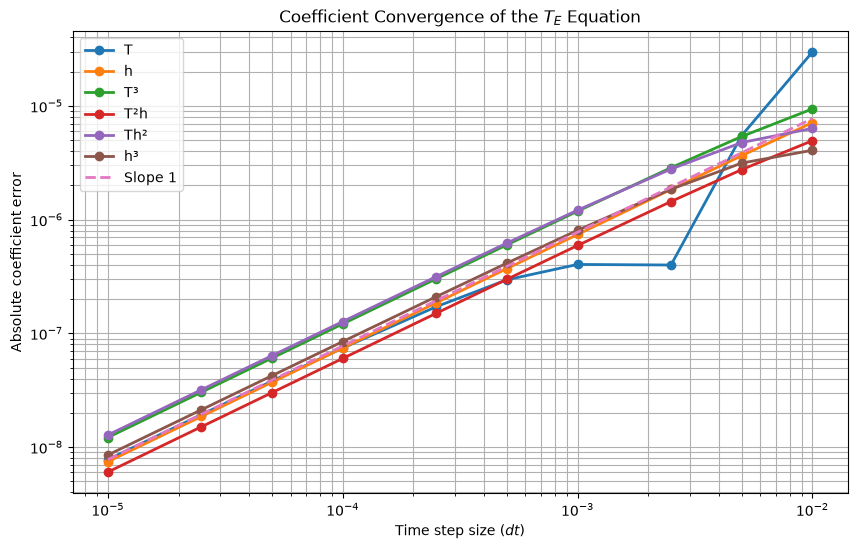

In [16]:
plt.figure(figsize=(10, 6))

error_cols = {
    "T(t)_error": "T",
    "h(t)_error": "h",
    "T(t)*T(t)*T(t)_error": "T³",
    "T(t)*T(t)*h(t)_error": "T²h",
    "T(t)*h(t)*h(t)_error": "Th²",
    "h(t)*h(t)*h(t)_error": "h³",
}

for col, name in error_cols.items():

    plt.loglog(
        weights_T["dt"],
        weights_T[col],
        marker="o",
        linewidth=2,
        label=name,
    )

dt_ref = np.array([
    weights_T["dt"].min(),
    weights_T["dt"].max(),
])

ref_line = (
    weights_T["T(t)_error"].iloc[0]
    * dt_ref
    / dt_ref[0]
)

plt.loglog(
    dt_ref,
    ref_line,
    "--",
    linewidth=2,
    label="Slope 1",
)

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("Absolute coefficient error")

plt.title(
    r"Coefficient Convergence of the $T_E$ Equation"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.show()

In [17]:
weights_T = weights_df[
    weights_df["equation"] == "T"
].copy()

weights_T = weights_T.sort_values("dt")

factor_cols = labels[1:]

rows = []

for _, row in weights_T.iterrows():

    coeffs = row[factor_cols]

    top5 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(5)
    )

    rows.append({
        "dt": row["dt"],
        "1st": f"{top5.index[0]} ({coeffs[top5.index[0]]:.5f})",
        "2nd": f"{top5.index[1]} ({coeffs[top5.index[1]]:.5f})",
        "3rd": f"{top5.index[2]} ({coeffs[top5.index[2]]:.5f})",
        "4th": f"{top5.index[3]} ({coeffs[top5.index[3]]:.5f})",
        "5th": f"{top5.index[4]} ({coeffs[top5.index[4]]:.5f})",
    })

top5_T = pd.DataFrame(rows)

top5_T

,dt,1st,2nd,3rd,4th,5th
0,0.000010,h(t) (0.00001),T(t) (0.00001),T(t)*T(t)*h(t) (-0.00000),T(t)*h(t)*h(t) (-0.00000),T(t)*T(t)*T(t) (-0.00000)
1,0.000025,h(t) (0.00003),T(t) (0.00001),T(t)*T(t)*h(t) (-0.00000),T(t)*h(t)*h(t) (-0.00000),T(t)*T(t)*T(t) (-0.00000)
2,0.000050,h(t) (0.00005),T(t) (0.00003),T(t)*T(t)*h(t) (-0.00001),T(t)*h(t)*h(t) (-0.00001),T(t)*T(t)*T(t) (-0.00000)
3,0.000100,h(t) (0.00010),T(t) (0.00005),T(t)*T(t)*h(t) (-0.00002),T(t)*h(t)*h(t) (-0.00001),T(t)*T(t)*T(t) (-0.00001)
4,0.000250,h(t) (0.00025),T(t) (0.00013),T(t)*T(t)*h(t) (-0.00004),T(t)*h(t)*h(t) (-0.00004),T(t)*T(t)*T(t) (-0.00001)
5,0.000500,h(t) (0.00050),T(t) (0.00025),T(t)*T(t)*h(t) (-0.00008),T(t)*h(t)*h(t) (-0.00007),T(t)*T(t)*T(t) (-0.00003)
6,0.001000,h(t) (0.00100),T(t) (0.00050),T(t)*T(t)*h(t) (-0.00015),T(t)*h(t)*h(t) (-0.00015),T(t)*T(t)*T(t) (-0.00005)
7,0.002500,h(t) (0.00250),T(t) (0.00125),T(t)*T(t)*h(t) (-0.00038),T(t)*h(t)*h(t) (-0.00037),T(t)*T(t)*T(t) (-0.00013)
8,0.005000,h(t) (0.00500),T(t) (0.00249),T(t)*T(t)*h(t) (-0.00075),T(t)*h(t)*h(t) (-0.00075),T(t)*T(t)*T(t) (-0.00026)
9,0.010000,h(t) (0.01001),T(t) (0.00497),T(t)*T(t)*h(t) (-0.00150),T(t)*h(t)*h(t) (-0.00149),T(t)*T(t)*T(t) (-0.00051)


### $dh_W/dt$ Equation

The Euler discretisation of the $h_W$ equation is

$$
h_{W,n+1}
=
h_{W,n}
+
dt\,\big[-rh_{W,n}-\alpha bT_{E,n}\big]
$$

In [18]:
weights_h = weights_df[
    weights_df["equation"] == "h"
].copy()

weights_h = weights_h.sort_values("dt")

for _, row in weights_h.iterrows():

    dt = row["dt"]

    print(f"\ndt = {dt}")

    print(
        "T      :",
        row["T(t)"],
        "|",
        -1.0*dt,
    )

    print(
        "h      :",
        row["h(t)"],
        "|",
        -0.5*dt,
    )


dt = 1e-05
T      : -1.000249162722525e-05 | -1e-05
h      : -5.003190375258459e-06 | -5e-06

dt = 2.5e-05
T      : -2.5006225743445852e-05 | -2.5e-05
h      : -1.250811479712769e-05 | -1.25e-05

dt = 5e-05
T      : -5.00124527872612e-05 | -5e-05
h      : -2.50166993316238e-05 | -2.5e-05

dt = 0.0001
T      : -0.00010002491072962059 | -0.0001
h      : -5.0035277588111444e-05 | -5e-05

dt = 0.00025
T      : -0.00025006231455871377 | -0.00025
h      : -0.00012510228541365051 | -0.000125

dt = 0.0005
T      : -0.0005001247487100745 | -0.0005
h      : -0.00025025153901828996 | -0.00025

dt = 0.001
T      : -0.0010002499293671524 | -0.001
h      : -0.0005006909261371771 | -0.0005

dt = 0.0025
T      : -0.0025006271345549822 | -0.0025
h      : -0.0012531356823896006 | -0.00125

dt = 0.005
T      : -0.005001255782857437 | -0.005
h      : -0.0025109626247624773 | -0.0025

dt = 0.01
T      : -0.010002471193682146 | -0.01
h      : -0.005040665471334531 | -0.005


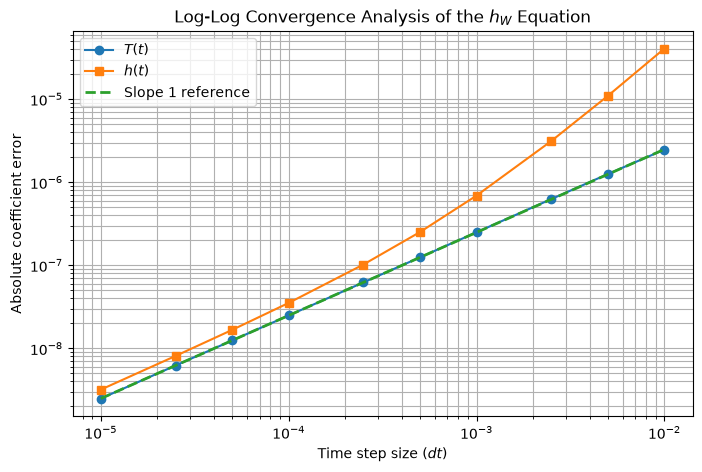

In [19]:
weights_h = weights_df[
    weights_df["equation"] == "h"
].copy()

weights_h = weights_h.sort_values("dt")

weights_h["Euler T(t)"] = (
    -1.0 * weights_h["dt"]
)

weights_h["Euler h(t)"] = (
    -0.5 * weights_h["dt"]
)

weights_h["T_error"] = np.abs(
    weights_h["T(t)"]
    - weights_h["Euler T(t)"]
)

weights_h["h_error"] = np.abs(
    weights_h["h(t)"]
    - weights_h["Euler h(t)"]
)

plt.figure(figsize=(8, 5))

plt.loglog(
    weights_h["dt"],
    weights_h["T_error"],
    marker="o",
    label=r"$T(t)$",
)

plt.loglog(
    weights_h["dt"],
    weights_h["h_error"],
    marker="s",
    label=r"$h(t)$",
)

dt_ref = np.array([
    weights_h["dt"].min(),
    weights_h["dt"].max(),
])

ref_line = (
    weights_h["T_error"].iloc[0]
    * dt_ref
    / dt_ref[0]
)

plt.loglog(
    dt_ref,
    ref_line,
    "--",
    linewidth=2,
    label="Slope 1 reference",
)

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("Absolute coefficient error")

plt.title(
    r"Log-Log Convergence Analysis of the $h_W$ Equation"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_h_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [20]:
weights_h = weights_df[
    weights_df["equation"] == "h"
].copy()

weights_h = weights_h.sort_values("dt")

factor_cols = labels[1:]

rows = []

for _, row in weights_h.iterrows():

    coeffs = row[factor_cols]

    top5 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(5)
    )

    rows.append({
        "dt": row["dt"],
        "1st": f"{top5.index[0]} ({coeffs[top5.index[0]]:.5f})",
        "2nd": f"{top5.index[1]} ({coeffs[top5.index[1]]:.5f})",
        "3rd": f"{top5.index[2]} ({coeffs[top5.index[2]]:.5f})",
        "4th": f"{top5.index[3]} ({coeffs[top5.index[3]]:.5f})",
        "5th": f"{top5.index[4]} ({coeffs[top5.index[4]]:.5f})",
    })

top5_h = pd.DataFrame(rows)

top5_h

,dt,1st,2nd,3rd,4th,5th
0,0.000010,T(t) (-0.00001),h(t) (-0.00001),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),T(t)*T(t)*T(t) (-0.00000)
1,0.000025,T(t) (-0.00003),h(t) (-0.00001),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),h(t)*h(t) (0.00000)
2,0.000050,T(t) (-0.00005),h(t) (-0.00003),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),h(t)*h(t) (0.00000)
3,0.000100,T(t) (-0.00010),h(t) (-0.00005),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),h(t)*h(t) (0.00000)
4,0.000250,T(t) (-0.00025),h(t) (-0.00013),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),h(t)*h(t) (0.00000)
5,0.000500,T(t) (-0.00050),h(t) (-0.00025),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),h(t)*h(t) (0.00000)
6,0.001000,T(t) (-0.00100),h(t) (-0.00050),h(t)*h(t)*h(t) (0.00000),T(t)*T(t)*h(t) (-0.00000),h(t)*h(t) (0.00000)
7,0.002500,T(t) (-0.00250),h(t) (-0.00125),h(t)*h(t)*h(t) (0.00000),T(t)*h(t)*h(t) (0.00000),h(t)*h(t) (0.00000)
8,0.005000,T(t) (-0.00500),h(t) (-0.00251),h(t)*h(t)*h(t) (0.00000),T(t)*h(t)*h(t) (0.00000),h(t)*h(t) (0.00000)
9,0.010000,T(t) (-0.01000),h(t) (-0.00504),T(t)*h(t)*h(t) (0.00001),h(t)*h(t)*h(t) (0.00001),T(t)*T(t)*h(t) (0.00000)


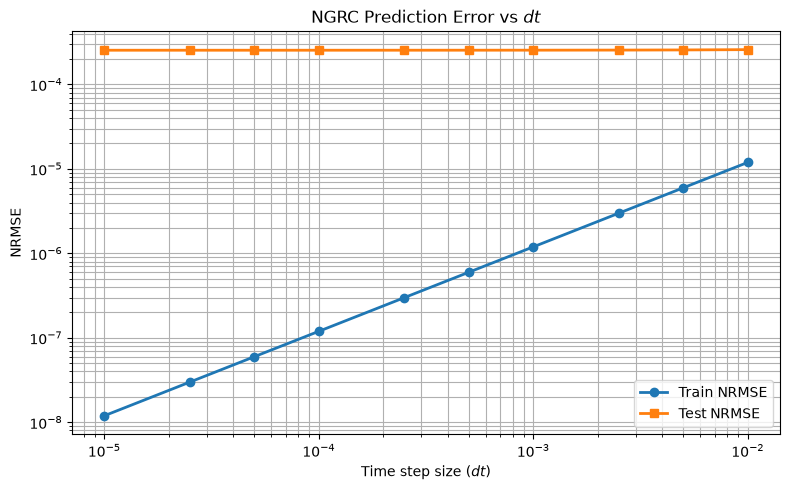

In [21]:
summary = pd.DataFrame([
    {
        "dt": r["dt"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results
])

summary = summary.sort_values("dt")

plt.figure(figsize=(8, 5))

plt.loglog(
    summary["dt"],
    summary["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.loglog(
    summary["dt"],
    summary["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("NRMSE")

plt.title(
    r"NGRC Prediction Error vs $dt$"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

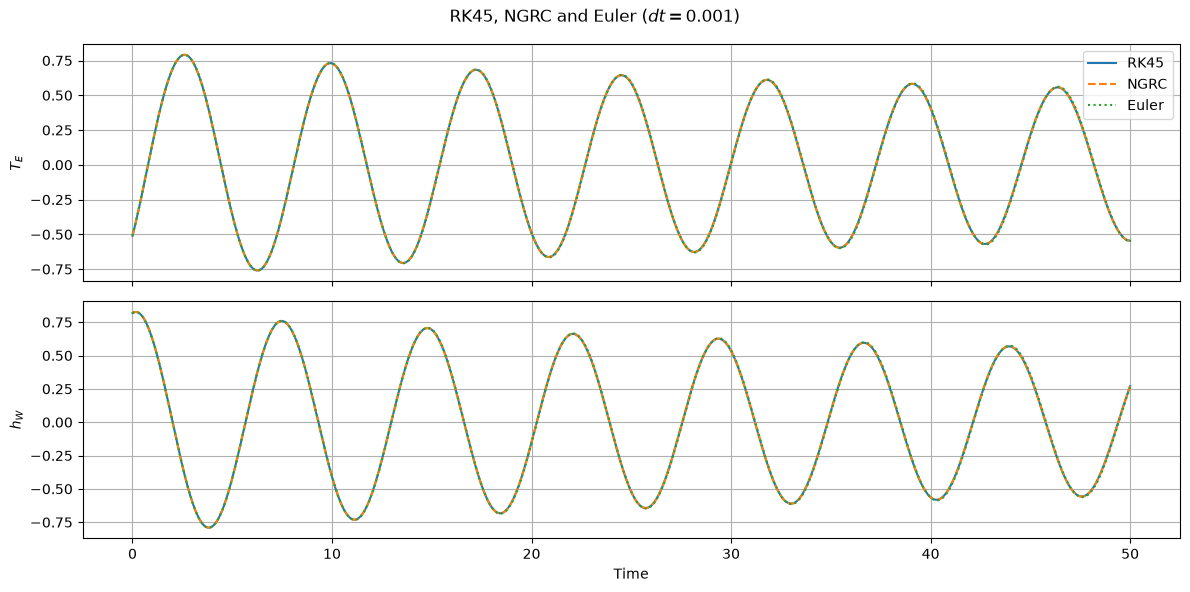

In [22]:
r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred = r["x_test"]

time = np.arange(
    pred.shape[1]
) * r["dt"]

euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred.shape[1],
    R=r["R"],
)

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12, 6),
    sharex=True,
)

for i, name in enumerate([
    r"$T_E$",
    r"$h_W$",
]):

    axs[i].plot(
        time,
        true[i],
        label="RK45",
    )

    axs[i].plot(
        time,
        pred[i],
        "--",
        label="NGRC",
    )

    axs[i].plot(
        time,
        euler[i],
        ":",
        label="Euler",
    )

    axs[i].set_ylabel(name)

    axs[i].grid(True)

axs[0].legend()

axs[-1].set_xlabel("Time")

plt.suptitle(
    rf"RK45, NGRC and Euler ($dt={r['dt']}$)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/rk45_ngrc_euler.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

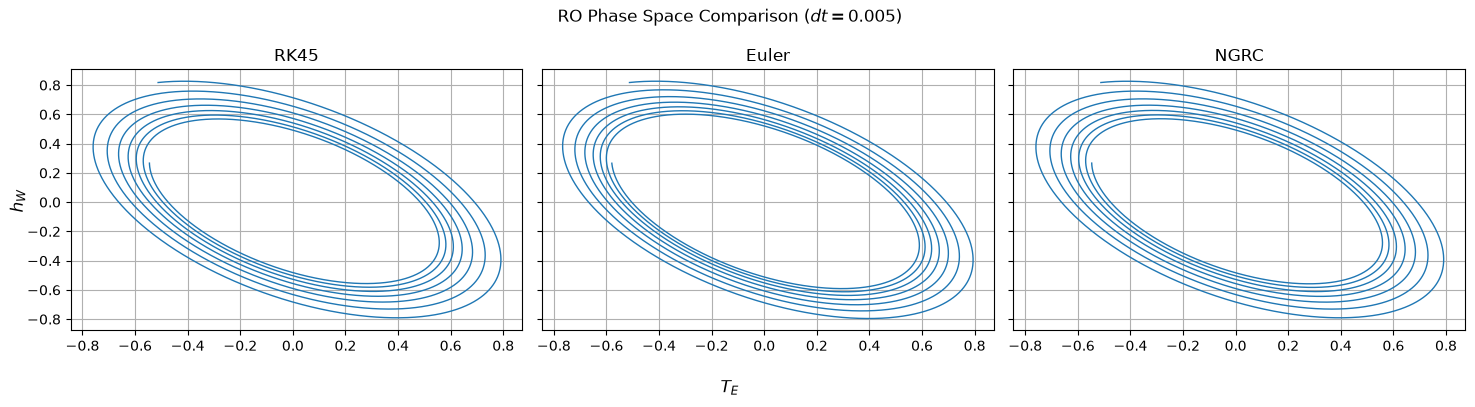

In [23]:
r = next(
    r for r in results
    if r["dt"] == 0.005
)

true = r["true_test"]

pred = r["x_test"]

euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred.shape[1],
    R=r["R"],
)

fig, axs = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharex=True,
    sharey=True,
)

for ax, x_data, title in zip(
    axs,
    [true, euler, pred],
    ["RK45", "Euler", "NGRC"],
):

    ax.plot(
        x_data[0],
        x_data[1],
        linewidth=1,
    )

    ax.set_title(title)

    ax.grid(True)

fig.supxlabel(r"$T_E$")

fig.supylabel(r"$h_W$")

plt.suptitle(
    rf"RO Phase Space Comparison ($dt={r['dt']}$)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/ro_phase_space_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [25]:
d = 2

k = 1

dt = 0.01

labels = build_labels(k=k)

ridge_values = [
    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10,
    100,
]

results_ridge = []

for ridge in ridge_values:

    results_ridge.append(
        run_experiment(
            dt=dt,
            ridge_param=ridge,
            k=k,
        )
    )

    print(f"Completed ridge={ridge}")

summary_ridge = pd.DataFrame([
    {
        "ridge": r["ridge"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results_ridge
])

summary_ridge = summary_ridge.sort_values(
    "ridge"
)

summary_ridge

Completed ridge=0
Completed ridge=1e-08
Completed ridge=1e-07
Completed ridge=1e-06
Completed ridge=1e-05
Completed ridge=0.0001
Completed ridge=0.001
Completed ridge=0.01
Completed ridge=0.1
Completed ridge=1
Completed ridge=10
Completed ridge=100


,ridge,train_nrmse,test_nrmse
0,0.000000e+00,0.000012,0.000258
1,1.000000e-08,0.000012,0.000258
2,1.000000e-07,0.000012,0.000258
3,1.000000e-06,0.000012,0.000258
4,1.000000e-05,0.000012,0.000259
5,1.000000e-04,0.000012,0.000265
6,1.000000e-03,0.000012,0.000470
7,1.000000e-02,0.000012,0.003627
8,1.000000e-01,0.000029,0.029867
9,1.000000e+00,0.000101,0.130332


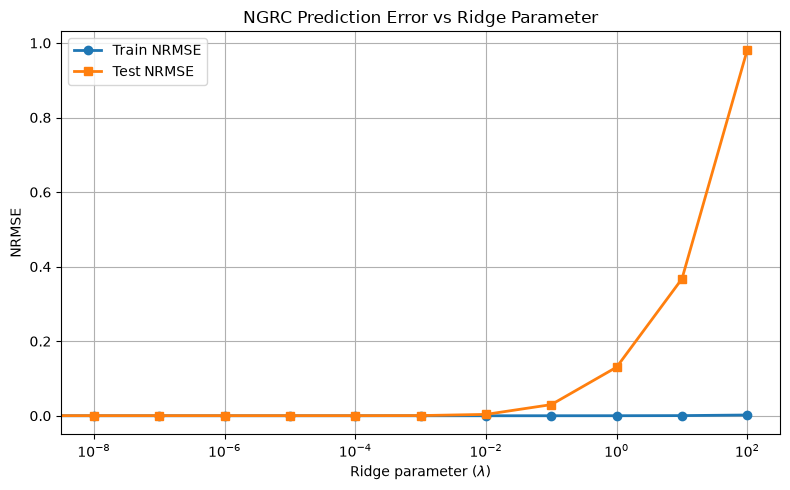

In [26]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel(r"Ridge parameter ($\lambda$)")

plt.ylabel("NRMSE")

plt.title(
    r"NGRC Prediction Error vs Ridge Parameter"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_ridge.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()